<a href="https://colab.research.google.com/github/michael-d-huynh/CPS-ABS----Labor-Force-Exposure-to-AI/blob/main/CPS_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import files
uploaded = files.upload()  # select CPS - 2020-2025.gz

Saving CPS - 2020-2025.gz to CPS - 2020-2025.gz


In [ ]:
df_ipums = pd.read_csv("CPS - 2020-2025.gz", compression="gzip")
print(df_ipums.shape)
print(df_ipums.columns.tolist())

(906757, 23)
['YEAR', 'SERIAL', 'MONTH', 'CPSID', 'ASECFLAG', 'ASECWTH', 'PERNUM', 'CPSIDP', 'CPSIDV', 'ASECWT', 'AGE', 'SEX', 'RACE', 'EMPSTAT', 'OCC', 'IND', 'CLASSWKR', 'UHRSWORKT', 'EDUC', 'WKSWORK2', 'FULLPART', 'INCWAGE', 'EARNWEEK']


In [ ]:
df_ipums.head(20)

,YEAR,SERIAL,MONTH,CPSID,ASECFLAG,ASECWTH,PERNUM,CPSIDP,CPSIDV,ASECWT,AGE,SEX,RACE,EMPSTAT,OCC,IND,CLASSWKR,UHRSWORKT,EDUC,WKSWORK2,FULLPART,INCWAGE,EARNWEEK
0,2020,1,3,20190302844900,1,1560.3756,1,20190302844901,201903028449011,1560.3756,63,2,100,10,440,9480,27,40,73,6,1,52500,9999.99
1,2020,1,3,20190302844900,1,1560.3756,2,20190302844902,201903028449021,1560.3756,67,1,100,36,0,0,0,999,73,4,1,56000,9999.99
2,2020,2,3,20181202843500,1,986.5948,1,20181202843501,201812028435011,986.5948,64,1,100,10,9121,7860,28,48,73,6,1,34000,654.00
3,2020,2,3,20181202843500,1,986.5948,2,20181202843502,201812028435021,986.5948,71,2,100,36,0,0,0,999,50,0,0,0,9999.99
4,2020,3,3,20190202831700,1,1519.0704,1,20190202831701,201902028317011,1519.0704,54,2,100,10,5500,6290,21,44,73,6,1,40000,9999.99
5,2020,4,3,20190302822300,1,1423.5779,1,20190302822301,201903028223011,1423.5779,74,2,100,32,0,0,0,999,73,0,0,0,9999.99
6,2020,4,3,20190302822300,1,1423.5779,2,20190302822302,201903028223021,1568.7101,37,1,100,10,3602,9290,21,21,73,6,2,8424,9999.99
7,2020,5,3,20181202835000,1,1151.5217,1,20181202835001,201812028350011,1151.5217,47,2,100,34,0,0,0,999,92,0,0,0,9999.99
8,2020,5,3,20181202835000,1,1151.5217,2,20181202835002,201812028350021,1151.5217,44,1,100,10,3870,9470,28,997,81,6,1,58000,225.00
9,2020,5,3,20181202835000,1,1151.5217,3,20181202835004,201812028350041,1317.4650,21,1,100,34,0,0,0,999,73,0,0,0,9999.99


In [ ]:
df_ipums.shape

(906757, 23)

In [ ]:
df_ipums_naics54 = df_ipums[df_ipums["IND"].between(7270, 7490)]
print(df_ipums_naics54.shape)

(34845, 23)


In [ ]:
print(df_ipums_naics54.columns.tolist())

['YEAR', 'SERIAL', 'MONTH', 'CPSID', 'ASECFLAG', 'ASECWTH', 'PERNUM', 'CPSIDP', 'CPSIDV', 'ASECWT', 'AGE', 'SEX', 'RACE', 'EMPSTAT', 'OCC', 'IND', 'CLASSWKR', 'UHRSWORKT', 'EDUC', 'WKSWORK2', 'FULLPART', 'INCWAGE', 'EARNWEEK']
YEAR           int64
SERIAL         int64
MONTH          int64
CPSID          int64
ASECFLAG       int64
ASECWTH      float64
PERNUM         int64
CPSIDP         int64
CPSIDV         int64
ASECWT       float64
AGE            int64
SEX            int64
RACE           int64
EMPSTAT        int64
OCC            int64
IND            int64
CLASSWKR       int64
UHRSWORKT      int64
EDUC           int64
WKSWORK2       int64
FULLPART       int64
INCWAGE        int64
EARNWEEK     float64
dtype: object


In [ ]:
print(df_ipums_naics54.dtypes)

YEAR           int64
SERIAL         int64
MONTH          int64
CPSID          int64
ASECFLAG       int64
ASECWTH      float64
PERNUM         int64
CPSIDP         int64
CPSIDV         int64
ASECWT       float64
AGE            int64
SEX            int64
RACE           int64
EMPSTAT        int64
OCC            int64
IND            int64
CLASSWKR       int64
UHRSWORKT      int64
EDUC           int64
WKSWORK2       int64
FULLPART       int64
INCWAGE        int64
EARNWEEK     float64
dtype: object


In [ ]:
df_ipums_naics54.head(15)

,YEAR,SERIAL,MONTH,CPSID,ASECFLAG,ASECWTH,PERNUM,CPSIDP,CPSIDV,ASECWT,AGE,SEX,RACE,EMPSTAT,OCC,IND,CLASSWKR,UHRSWORKT,EDUC,WKSWORK2,FULLPART,INCWAGE,EARNWEEK
50,2020,30,3,20200202811500,1,1644.1361,1,20200202811501,202002028115011,1644.1361,60,2,100,10,3602,7380,21,40,81,3,1,40000,9999.99
86,2020,73,3,20190202823600,1,978.4691,3,20190202823604,201902028236041,978.4691,34,1,100,10,440,7380,27,40,111,6,1,65000,9999.99
124,2020,108,3,20200102784000,1,1227.2432,2,20200102784002,202001027840021,1227.2432,65,2,100,12,2840,7390,21,40,111,6,1,80000,9999.99
201,2020,206,3,20200302783300,1,1629.4291,2,20200302783302,202003027833021,1629.4291,61,2,100,10,5120,7280,13,48,73,6,1,0,9999.99
294,2020,325,3,20190302826000,1,1798.4878,2,20190302826002,201903028260021,1798.4878,58,1,100,10,5240,7380,27,40,111,6,1,85000,9999.99
319,2020,340,3,20181202819000,1,1720.3780,2,20181202819002,201812028190021,1720.3780,31,2,100,10,3422,7480,21,40,111,6,1,34000,640.00
408,2020,395,3,20201300039500,1,901.4916,1,20201300039501,202013000395011,901.4916,48,2,100,10,710,7380,21,40,73,6,1,53000,9999.99
412,2020,397,3,20201300039700,1,1276.3448,1,20201300039701,202013000397011,1276.3448,47,1,100,10,4850,7390,21,36,92,2,1,5500,9999.99
461,2020,420,3,20200102829700,1,760.3794,1,20200102829701,202001028297011,760.3794,43,1,100,10,1021,7380,21,40,73,6,1,145000,9999.99
472,2020,425,3,20190302873100,1,1761.3230,1,20190302873101,201903028731011,1761.3230,74,1,100,10,710,7390,13,32,123,2,2,0,9999.99


In [ ]:
print("Summary Stats: \n", df_ipums_naics54.describe())

Summary Stats: 
                YEAR        SERIAL    MONTH         CPSID  ASECFLAG  \
count  34845.000000  34845.000000  34845.0  3.484500e+04   34845.0   
mean    2022.472062  45602.210733      3.0  2.021975e+13       1.0   
std        1.717157  27370.826203      0.0  1.841844e+10       0.0   
min     2020.000000     11.000000      3.0  2.018120e+13       1.0   
25%     2021.000000  21049.000000      3.0  2.020131e+13       1.0   
50%     2022.000000  43400.000000      3.0  2.022030e+13       1.0   
75%     2024.000000  71701.000000      3.0  2.023131e+13       1.0   
max     2025.000000  91491.000000      3.0  2.025131e+13       1.0   

            ASECWTH        PERNUM        CPSIDP        CPSIDV        ASECWT  \
count  34845.000000  34845.000000  3.484500e+04  3.484500e+04  34845.000000   
mean    2358.027067      1.532989  2.021981e+13  2.021981e+14   2397.740184   
std     1398.151599      0.775058  1.842601e+10  1.842601e+11   1445.116866   
min      118.343700      1.000000  2

In [ ]:
# Check suspicious values per column
for col in ["EARNWEEK", "UHRSWORKT", "WKSWORK2", "INCWAGE"]:
    print(f"\n{col} value counts (top 10):")
    print(df_ipums_naics54[col].value_counts().head(10))


EARNWEEK value counts (top 10):
EARNWEEK
9999.99    19972
2885.00      596
1923.00      103
1442.00       82
1346.00       67
2308.00       56
1154.00       54
1538.00       53
2115.00       51
2500.00       49
Name: count, dtype: int64

UHRSWORKT value counts (top 10):
UHRSWORKT
40     19800
50      2736
997     1863
45      1764
999     1258
60      1169
20       796
30       633
55       585
35       548
Name: count, dtype: int64

WKSWORK2 value counts (top 10):
WKSWORK2
6    29686
4     1127
2     1122
0      828
3      821
1      647
5      614
Name: count, dtype: int64

INCWAGE value counts (top 10):
INCWAGE
0         3141
100000    1243
150000    1114
60000      940
50000      885
120000     830
80000      830
75000      757
70000      742
90000      669
Name: count, dtype: int64


In [ ]:
print(df_ipums_naics54["IND"].value_counts().sort_index())

IND
7270     4436
7280     3314
7290     4849
7370     1105
7380    10149
7390     4889
7460     2186
7470     1540
7480     1072
7490     1305
Name: count, dtype: int64


In [ ]:
# Step 1: check sentinel values
for col in ["EARNWEEK", "UHRSWORKT", "WKSWORK2", "INCWAGE"]:
    print(f"{col}: {sorted(df_ipums_naics54[col].unique())[-8:]}")

EARNWEEK: [np.float64(2862.0), np.float64(2865.0), np.float64(2877.0), np.float64(2880.0), np.float64(2884.0), np.float64(2885.0), np.float64(9999.99), np.float64(nan)]
UHRSWORKT: [np.int64(99), np.int64(100), np.int64(112), np.int64(113), np.int64(119), np.int64(120), np.int64(997), np.int64(999)]
WKSWORK2: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
INCWAGE: [np.int64(1100999), np.int64(1101499), np.int64(1107499), np.int64(1154999), np.int64(1360000), np.int64(1399999), np.int64(1550000), np.int64(1569999)]


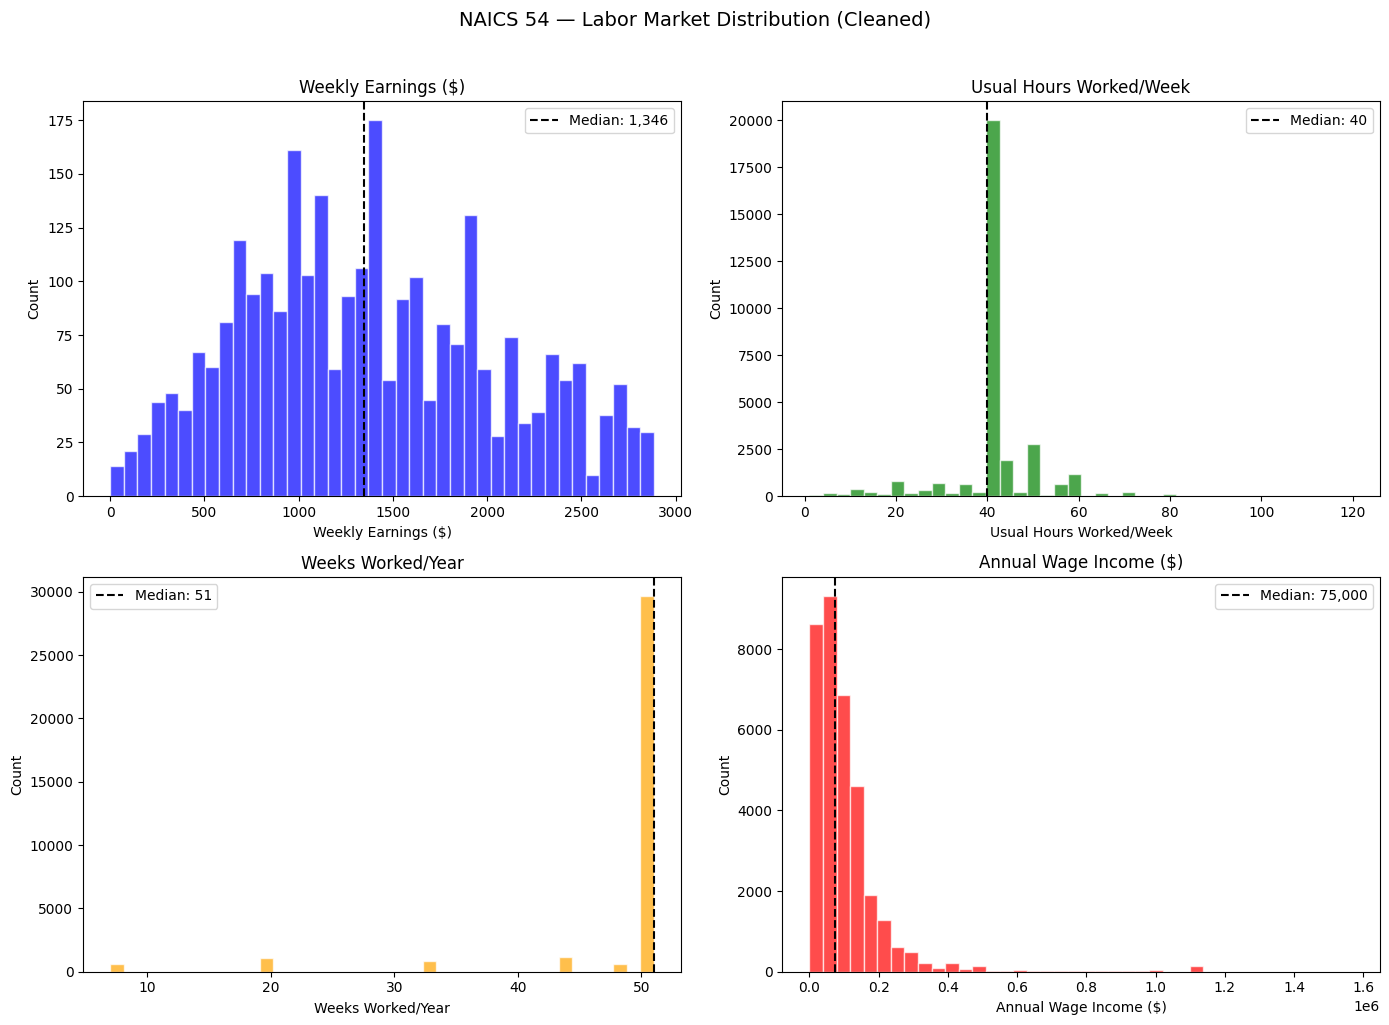

In [ ]:
# Step 2: clean
df_ipums_naics54_clean = df_ipums_naics54.copy()

# EARNWEEK — topcode at 2885 AND missing at 9999.99
df_ipums_naics54_clean["EARNWEEK"] = df_ipums_naics54_clean["EARNWEEK"].replace(9999.99, np.nan)
df_ipums_naics54_clean.loc[df_ipums_naics54_clean["EARNWEEK"] >= 2885, "EARNWEEK"] = np.nan

# UHRSWORKT — 999 AND 997 (hours vary) are sentinels
df_ipums_naics54_clean["UHRSWORKT"] = df_ipums_naics54_clean["UHRSWORKT"].replace([999, 997], np.nan)

# WKSWORK2 — categorical, replace with midpoints
wks_map = {1: 7, 2: 20, 3: 33, 4: 43.5, 5: 48.5, 6: 51}
df_ipums_naics54_clean["WKSWORK2"] = df_ipums_naics54_clean["WKSWORK2"].map(wks_map)

# INCWAGE
df_ipums_naics54_clean["INCWAGE"] = df_ipums_naics54_clean["INCWAGE"].replace(9999999, np.nan)

# Replot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
configs = [
    ("EARNWEEK",  "Weekly Earnings ($)",     "blue"),
    ("UHRSWORKT", "Usual Hours Worked/Week", "green"),
    ("WKSWORK2",  "Weeks Worked/Year",       "orange"),
    ("INCWAGE",   "Annual Wage Income ($)",  "red"),
]
for ax, (col, label, color) in zip(axes.flatten(), configs):
    data = df_ipums_naics54_clean[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(data.median(), color="black", linestyle="--", label=f"Median: {data.median():,.0f}")
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("NAICS 54 — Labor Market Distribution (Cleaned)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print("OCC unique vals:", sorted(df_ipums_naics54_clean["OCC"].unique()))
print("OCC value counts:\n", df_ipums_naics54_clean["OCC"].value_counts().head(20))

OCC unique vals: [np.int64(10), np.int64(20), np.int64(40), np.int64(51), np.int64(52), np.int64(60), np.int64(101), np.int64(102), np.int64(110), np.int64(120), np.int64(135), np.int64(136), np.int64(137), np.int64(140), np.int64(150), np.int64(160), np.int64(205), np.int64(220), np.int64(230), np.int64(300), np.int64(335), np.int64(340), np.int64(350), np.int64(360), np.int64(410), np.int64(420), np.int64(425), np.int64(440), np.int64(500), np.int64(510), np.int64(520), np.int64(530), np.int64(540), np.int64(565), np.int64(600), np.int64(630), np.int64(640), np.int64(650), np.int64(700), np.int64(705), np.int64(710), np.int64(725), np.int64(726), np.int64(735), np.int64(750), np.int64(800), np.int64(810), np.int64(820), np.int64(830), np.int64(845), np.int64(850), np.int64(860), np.int64(910), np.int64(930), np.int64(940), np.int64(960), np.int64(1005), np.int64(1006), np.int64(1007), np.int64(1010), np.int64(1021), np.int64(1022), np.int64(1031), np.int64(1032), np.int64(1050), np.i

In [ ]:
occ_labels = {
    # Management
    10: "Chief Executives",
    110: "Computer/IS Managers",
    # Business/Financial
    710: "Accountants/Auditors",
    # Computer/Math — highest AI exposure
    1005: "Computer/IS Researchers",
    1006: "Software Developers",
    1007: "Software QA",
    1010: "Web Developers",
    1021: "Computer Programmers",
    1022: "Software Engineers",
    1031: "Cybersecurity",
    1032: "Network/Systems",
    1050: "IT Support",
    1065: "Database Admins",
    1105: "Network Architects",
    1108: "Network/Telecom",
    # Architecture/Engineering
    1305: "Architects",
    1360: "Civil Engineers",
    # Legal
    2100: "Lawyers",
    2145: "Paralegals",
}

df_occ = df_ipums_naics54_clean[df_ipums_naics54_clean["OCC"].isin(occ_labels.keys())].copy()
df_occ["OCC_LABEL"] = df_occ["OCC"].map(occ_labels)

print("Matched rows:", len(df_occ))
print(df_occ.groupby("OCC_LABEL")["EARNWEEK"].agg(["median","count"]).sort_values("median", ascending=False))

Matched rows: 13675
                         median  count
OCC_LABEL                             
Software QA              1942.0     12
Chief Executives         1923.0     44
Software Engineers       1782.0     10
Software Developers      1760.0     45
Computer/IS Managers     1730.5     60
Lawyers                  1730.0    113
Computer Programmers     1730.0    193
Architects               1675.5     22
Web Developers           1625.0     50
Database Admins          1588.5     12
Computer/IS Researchers  1570.0      2
Cybersecurity            1542.0      9
Civil Engineers          1481.0     77
Accountants/Auditors     1442.0     93
Network Architects       1423.0     16
Network/Telecom          1365.0     56
IT Support               1160.0     57
Paralegals                962.0     85
Network/Systems           820.0      9


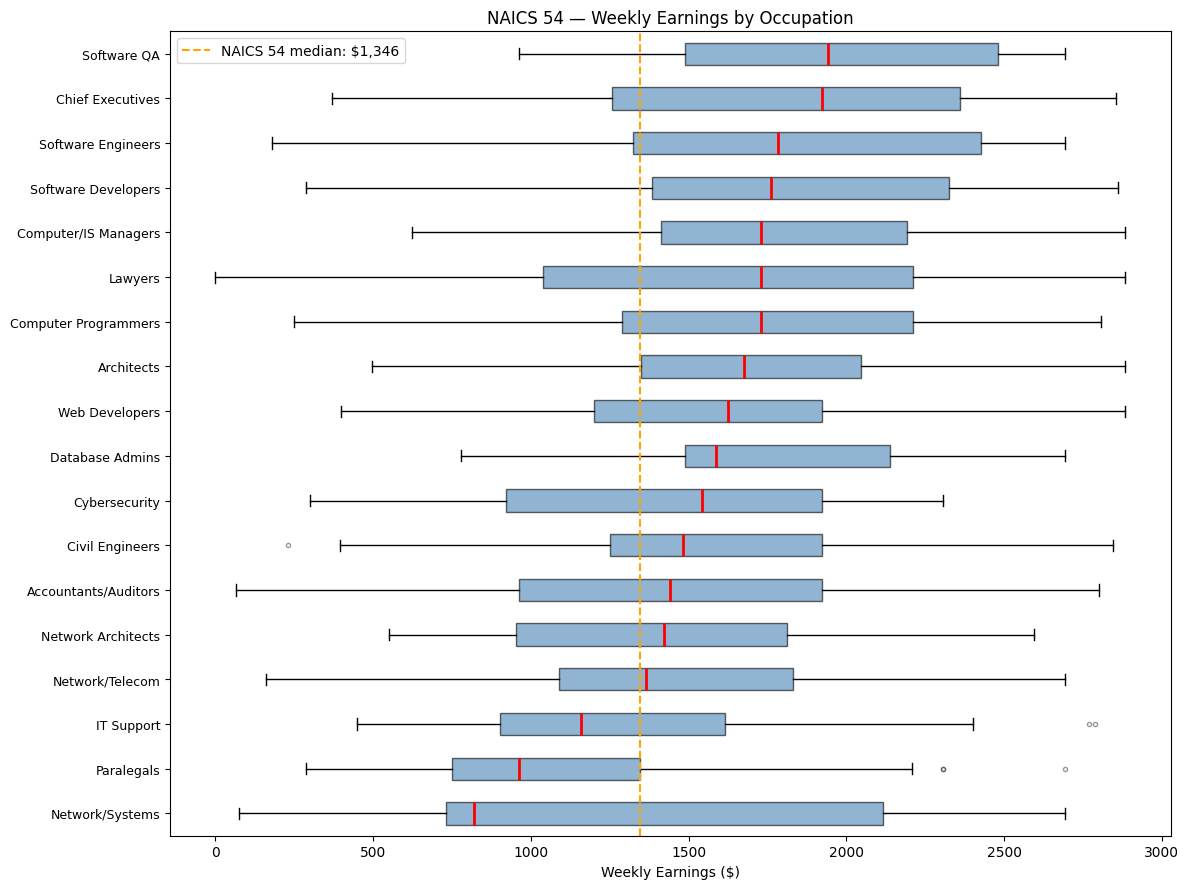

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

occ_labels = {
    10:   "Chief Executives",
    110:  "Computer/IS Managers",
    710:  "Accountants/Auditors",
    1005: "Computer/IS Researchers",
    1006: "Software Developers",
    1007: "Software QA",
    1010: "Web Developers",
    1021: "Computer Programmers",
    1022: "Software Engineers",
    1031: "Cybersecurity",
    1032: "Network/Systems",
    1050: "IT Support",
    1065: "Database Admins",
    1105: "Network Architects",
    1108: "Network/Telecom",
    1305: "Architects",
    1360: "Civil Engineers",
    2100: "Lawyers",
    2145: "Paralegals",
}

df_occ = df_ipums_naics54_clean[df_ipums_naics54_clean["OCC"].isin(occ_labels.keys())].copy()
df_occ["OCC_LABEL"] = df_occ["OCC"].map(occ_labels)

# Build sorted groups
groups = {label: df_occ[df_occ["OCC_LABEL"] == label]["EARNWEEK"].dropna().values
          for label in occ_labels.values()}
groups = {k: v for k, v in groups.items() if len(v) > 5}
sorted_groups = sorted(groups.items(), key=lambda x: np.median(x[1]))

labels = [g[0] for g in sorted_groups]
data   = [g[1] for g in sorted_groups]

fig, ax = plt.subplots(figsize=(12, 9))
bp = ax.boxplot(data, vert=False, patch_artist=True,
                medianprops=dict(color="red", linewidth=2),
                flierprops=dict(marker="o", markersize=3, alpha=0.4))

for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)

ax.set_yticks(range(1, len(labels)+1))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Weekly Earnings ($)")
ax.set_title("NAICS 54 — Weekly Earnings by Occupation")
ax.axvline(df_ipums_naics54_clean["EARNWEEK"].median(), color="orange", linestyle="--",
           label=f"NAICS 54 median: ${df_ipums_naics54_clean['EARNWEEK'].median():,.0f}")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

df_occ.to_csv("/content/drive/MyDrive/LaborLens/df_occ.csv", index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
